# OptiScore — 포지션별 선수 시장 가치 예측 모델

5대 리그(분데스리가/라리가/프리미어리그/세리에A/리그1) 필드 플레이어의 시즌 스탯으로
Transfermarkt 시장 가치를 예측하는 XGBoost 모델을 포지션 그룹(8개)별로 학습한다.

이 노트북은 실제 학습 파이프라인인 [`ml/train.py`](../train.py)와
[`backend/features.py`](../../backend/features.py)를 그대로 불러와서 실행한다 —
로직을 노트북에 다시 손코딩하지 않는 이유는, 이전 버전에서 학습 코드와 서빙(예측
API) 코드에 피처 엔지니어링을 각각 손코딩했다가 `'태클'` vs `'태클 성공'` 같은
불일치 버그가 생겼기 때문이다. 이제 두 곳 모두 `features.py` 하나만 본다.

**이전 버전 대비 수정한 것** (자세한 내용은 [`../reports/model_evaluation.md`](../reports/model_evaluation.md)):
1. 8개 포지션 모델을 전부 저장 (기존엔 마지막 포지션 모델만 저장되는 버그가 있었음)
2. StandardScaler 제거 — XGBoost엔 불필요했고, 스케일러를 저장하지 않아 서빙 시
   스케일이 어긋나는 버그가 있었음
3. `train_test_split`을 선수 단위(`GroupShuffleSplit`)로 — 기존 랜덤 분할은 같은
   선수의 여러 시즌이 train/test에 걸쳐 섞이는 데이터 누수가 있었음
4. `early_stopping_rounds`로 과적합 억제

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT / "backend"))
sys.path.insert(0, str(ROOT / "ml"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import features
import train as train_module

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")

## 1. 데이터 로딩 · 클리닝 · 피처 엔지니어링

In [2]:
raw = train_module.load_raw()
df = train_module.load_data()
print(f"학습 대상: {len(df):,}건, 선수 {df['name_key'].nunique():,}명, 포지션 그룹 {df['포지션_그룹'].nunique()}개")
df[["name_key", "시즌", "포지션_그룹", "TM_시장가치_EUR", "log_현재_시장가치", "log_전시즌_시장가치"]].head()

학습 대상: 11,637건, 선수 3,929명, 포지션 그룹 8개


,name_key,시즌,포지션_그룹,TM_시장가치_EUR,log_현재_시장가치,log_전시즌_시장가치
7938,aaron connolly,2019-2020,스트라이커,3666667.0,15.114794,0.000000
7179,aaron cresswell,2016-2017,중앙 수비수,12000000.0,16.300417,0.000000
7358,aaron cresswell,2017-2018,중앙 수비수,12000000.0,16.300417,16.300417
7573,aaron cresswell,2018-2019,중앙 수비수,10000000.0,16.118096,16.300417
7896,aaron cresswell,2019-2020,중앙 수비수,7500000.0,15.830414,16.118096


## 2. 포지션별 학습: 선수 그룹 분할 vs 기존 랜덤 분할

`_eval_naive_split`은 기존 코드와 동일한 완전 랜덤 분할(비교용, 데이터 누수 있음),
`_eval_grouped_split`은 선수 단위로 묶어 나누고 조기 종료를 적용한 수정 버전이다.
최종 저장되는 모델은 후자로 학습한 모델이다.

In [3]:
bundle, results = train_module.train_all(df)

공격형 미드필더: 랜덤분할 R²=68.73% -> 그룹분할 R²=77.44% (n=1012, best_iter=148)


수비형 미드필더: 랜덤분할 R²=68.98% -> 그룹분할 R²=66.75% (n=1378, best_iter=278)


스트라이커: 랜덤분할 R²=74.98% -> 그룹분할 R²=67.42% (n=1764, best_iter=436)


윙어: 랜덤분할 R²=75.21% -> 그룹분할 R²=62.13% (n=1357, best_iter=65)


중앙 미드필더: 랜덤분할 R²=77.65% -> 그룹분할 R²=69.05% (n=1455, best_iter=58)


중앙 수비수: 랜덤분할 R²=75.56% -> 그룹분할 R²=76.76% (n=2511, best_iter=408)


측면 미드필더: 랜덤분할 R²=48.44% -> 그룹분할 R²=40.26% (n=356, best_iter=443)


측면 수비수: 랜덤분할 R²=75.82% -> 그룹분할 R²=67.93% (n=1804, best_iter=213)


In [4]:
summary = pd.DataFrame([
    {
        "포지션": pos,
        "표본수": d["n_rows"],
        "선수수": d["n_players"],
        "R² (기존 랜덤분할)": d["naive_split"]["r2"],
        "R² (선수그룹분할)": d["grouped_split"]["r2"],
        "RMSE (그룹분할, EUR)": d["grouped_split"]["rmse"],
        "실제 트리 수": d["grouped_split"]["best_iteration"],
    }
    for pos, d in results.items()
]).sort_values("R² (선수그룹분할)", ascending=False)
summary.style.format({
    "R² (기존 랜덤분할)": "{:.1%}", "R² (선수그룹분할)": "{:.1%}", "RMSE (그룹분할, EUR)": "{:,.0f}"
})

,포지션,표본수,선수수,R² (기존 랜덤분할),R² (선수그룹분할),"RMSE (그룹분할, EUR)",실제 트리 수
0,공격형 미드필더,1012,336,68.7%,77.4%,"12,229,261",148
5,중앙 수비수,2511,868,75.6%,76.8%,"7,934,032",408
4,중앙 미드필더,1455,501,77.6%,69.0%,"8,928,466",58
7,측면 수비수,1804,627,75.8%,67.9%,"6,702,840",213
2,스트라이커,1764,607,75.0%,67.4%,"10,418,994",436
1,수비형 미드필더,1378,422,69.0%,66.8%,"13,784,700",278
3,윙어,1357,462,75.2%,62.1%,"15,891,850",65
6,측면 미드필더,356,162,48.4%,40.3%,"5,312,775",443


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\1438039886.py:10: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\1438039886.py:10: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\1438039886.py:10: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\1438039886.py:10: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\1438039886.py:10: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\1438039886.py:10: UserWarning: Gl

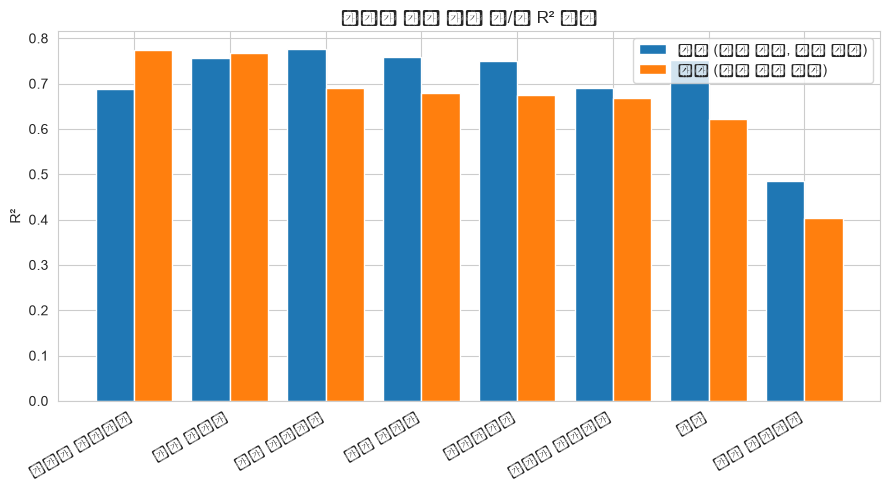

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(summary))
ax.bar([i - 0.2 for i in x], summary["R² (기존 랜덤분할)"], width=0.4, label="기존 (랜덤 분할, 누수 있음)")
ax.bar([i + 0.2 for i in x], summary["R² (선수그룹분할)"], width=0.4, label="수정 (선수 그룹 분할)")
ax.set_xticks(list(x))
ax.set_xticklabels(summary["포지션"], rotation=30, ha="right")
ax.set_ylabel("R²")
ax.set_title("데이터 누수 수정 전/후 R² 비교")
ax.legend()
fig.tight_layout()
plt.show()

8개 중 6개 포지션에서 선수 그룹 분할 R²가 기존보다 낮다 — 기존 랜덤 분할이 데이터
누수로 성능을 낙관적으로 보고하고 있었다는 뜻이다. 자세한 해석은
[`model_evaluation.md`](../reports/model_evaluation.md) 1절 참고.

## 3. 피처 중요도 — 스트라이커 예시

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\3636688600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\3636688600.py:9: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\3636688600.py:9: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\3636688600.py:9: UserWarning: Glyph 51596 (\N{HANGUL SYLLABLE JEUN}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\3636688600.py:9: UserWarning: Glyph 51109 (\N{HANGUL SYL

C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


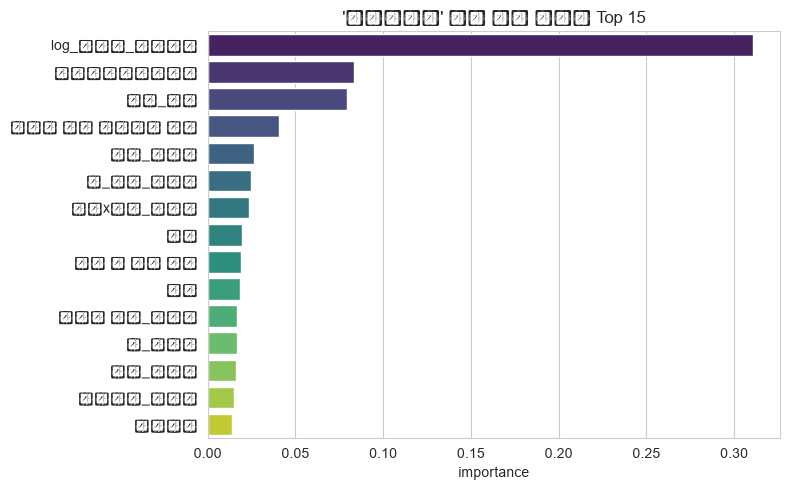

In [6]:
example_position = "스트라이커"
imp_df = pd.DataFrame(results[example_position]["top_features"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, palette="viridis")
ax.set_title(f"'{example_position}' 모델 피처 중요도 Top 15")
ax.set_xlabel("importance")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

전 포지션에서 `log_전시즌_시장가치`(작년 시장 가치)가 1위다. 시장가치는 원래
전년도 값과 강한 자기상관이 있어 자연스러운 결과이지만, 이 모델이 "성과로부터 가치를
추정"한다기보다 "작년 가격 + 보정"에 가깝다는 한계이기도 하다.

## 4. 오차 분석 — 과소평가된 슈퍼스타

In [7]:
under = pd.DataFrame(results[example_position]["underrated_top5"])
over = pd.DataFrame(results[example_position]["overrated_top5"])

print(f"[{example_position}] 과소평가 TOP 5 (모델이 실제보다 훨씬 낮게 예측)")
display(under)
print(f"\n[{example_position}] 과대평가 TOP 5 (모델이 실제보다 훨씬 높게 예측)")
display(over)

[스트라이커] 과소평가 TOP 5 (모델이 실제보다 훨씬 낮게 예측)


,선수명,실제_가치,예측_가치,오차
0,luis suárez,90000000.0,27953988.0,-62046012.0
1,harry kane,116666667.0,56403700.0,-60262967.0
2,gonzalo higuain,75000000.0,19630048.0,-55369952.0
3,harry kane,150000000.0,100012424.0,-49987576.0
4,harry kane,135000000.0,87255680.0,-47744320.0



[스트라이커] 과대평가 TOP 5 (모델이 실제보다 훨씬 높게 예측)


,선수명,실제_가치,예측_가치,오차
0,paulinho,4750000.0,35772660.0,31022660.0
1,harry kane,82500000.0,112281112.0,29781112.0
2,alexis sánchez,11166667.0,35874332.0,24707665.0
3,joao pedro,10500000.0,33012188.0,22512188.0
4,moussa dembélé,18500000.0,37229052.0,18729052.0


Luis Suárez, Harry Kane처럼 브랜드 가치·이적시장 하이프가 큰 선수는 일관되게
과소평가된다 — 시즌 스탯만으로는 설명되지 않는 "시장 프리미엄"이 있다는 뜻이다.
다른 포지션(윙어의 Eden Hazard/Son Heung-min/Bukayo Saka, 중앙 수비수의
Matthijs de Ligt 등)에서도 동일한 패턴이 반복된다 — 자세한 목록은
[`model_evaluation.md`](../reports/model_evaluation.md) 4절 참고.

## 5. 잔차 분석

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\4023203639.py:17: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\4023203639.py:17: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\4023203639.py:17: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\4023203639.py:17: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\4023203639.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_41696\4023203639.py:17: UserWarning: Glyph 52

C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SONGSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python

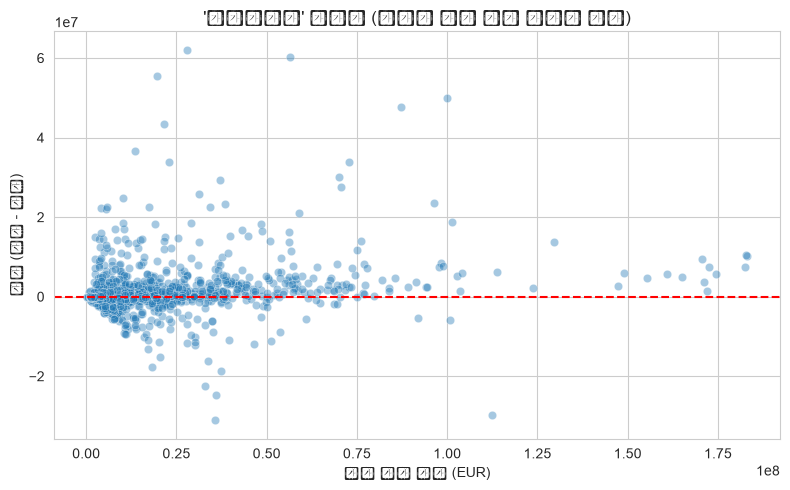

In [8]:
group_df = df[df["포지션_그룹"] == example_position].copy()
X, y = train_module._make_xy(group_df)
model = bundle[example_position]["model"]

import numpy as np
log_pred = model.predict(X[bundle[example_position]["feature_cols"]])
y_pred = np.expm1(log_pred)
y_true = np.expm1(y)
residuals = y_true - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=ax)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("예측 시장 가치 (EUR)")
ax.set_ylabel("잔차 (실제 - 예측)")
ax.set_title(f"'{example_position}' 잔차도 (학습에 쓰인 전체 데이터 기준)")
fig.tight_layout()
plt.show()

## 6. 모델 저장

포지션별 모델을 전부 `backend/models/model_bundle.pkl`에 저장한다 (기존 버그였던
"마지막 포지션 모델만 저장" 문제 수정). `backend/app.py`는 이 번들을 로드해서
선수 포지션에 맞는 모델로 예측한다.

In [9]:
import joblib

BUNDLE_PATH = ROOT / "backend" / "models" / "model_bundle.pkl"
joblib.dump(bundle, BUNDLE_PATH)
print(f"저장 완료: {BUNDLE_PATH} ({len(bundle)}개 포지션)")

pred_df = train_module.predict_all(df, bundle)
out = train_module.build_prediction_excel(raw, pred_df)
out.to_excel(ROOT / "data" / "player_with_pred.xlsx", index=False)
print("예측 결과 저장 완료: data/player_with_pred.xlsx")

저장 완료: C:\Users\SONGSH\Desktop\capstone_design\backend\models\model_bundle.pkl (8개 포지션)


예측 결과 저장 완료: data/player_with_pred.xlsx


## 7. 한계 및 향후 개선 과제

1. **측면 미드필더**는 표본이 356건(162명)으로 가장 적어 R²(40.3%)가 다른 포지션 대비 낮다.
2. **슈퍼스타 과소평가**: 시즌 스탯만으로는 브랜드/하이프 요인을 설명하지 못한다.
3. **신인 선수**: "작년 시장 가치"가 없는 데뷔 시즌 선수에 대한 예측 정확도는 별도 검증이 필요하다.
4. **더 엄격한 검증**: 지금의 선수 그룹 분할도 여전히 "무작위 선수"를 떼어내는 것이라,
   실제 배포 시나리오(과거 시즌으로 학습해 미래 시즌을 예측)보다는 관대한 평가다.
   시즌 기준 시간 분할(예: 2023-24 이전 시즌 학습 → 2024-25 시즌 테스트)이 다음 단계로
   더 적합하다.